In [2]:
import json
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

from pgmpy.estimators import HillClimbSearch, BayesianEstimator, BicScore

from pgmpy.models import BayesianNetwork
from pgmpy.inference import VariableElimination

In [3]:
rows = []

with open("/Users/carolwang/Desktop/yelp_business.json", "r", encoding="utf-8") as file:
    for line in file:
        business = json.loads(line)

        # iclude "restaurant" businesses only 
        categories = business.get("categories")
        if categories is None or "Restaurants" not in categories:
            continue

        attrs = business.get("attributes", {})
        if attrs is None:
            attrs = {}

        rows.append({
            # continuous features
            "stars": business.get("stars"),
            "review_count": business.get("review_count"),

            # categorical features
            "price_range": attrs.get("RestaurantsPriceRange2", "Unknown"),
            #"noise_level": attrs.get("NoiseLevel", "Unknown"),
            #"wifi": attrs.get("WiFi", "Unknown"),
            
            # boolean features
            "BusinessAcceptsCreditCards": attrs.get("BusinessAcceptsCreditCards"),
            "delivery": attrs.get("RestaurantsDelivery", "Unknown"),
            "takeout": attrs.get("RestaurantsTakeOut", "Unknown"),
            "reservations": attrs.get("RestaurantsReservations", "Unknown"),
            "outdoor_seating": attrs.get("OutdoorSeating", "Unknown"),
            #"good_for_groups": attrs.get("RestaurantsGoodForGroups", "Unknown")     
        })

df = pd.DataFrame(rows)
print(df.shape)
print(df.head())

(52268, 8)
   stars  review_count price_range BusinessAcceptsCreditCards delivery  \
0    4.0            80           1                      False    False   
1    2.0             6           1                       True     True   
2    3.0            19           1                       True    False   
3    1.5            10           1                       True     True   
4    4.0            10     Unknown                       None  Unknown   

   takeout reservations outdoor_seating  
0     True      Unknown           False  
1     True        False            True  
2     True        False            True  
3     True        False            True  
4  Unknown        False            None  


In [14]:
# remove sparse cols: noise_level, wifi, and good_for_groups 
for col in df.columns:
    missing_ratio = (df[col] == "Unknown").mean()
    print(f"ratio of missing {col}: {round(missing_ratio, 4)}")

ratio of missing stars: 0.0
ratio of missing review_count: 0.0
ratio of missing price_range: 0.1486
ratio of missing noise_level: 0.3333
ratio of missing wifi: 0.2778
ratio of missing BusinessAcceptsCreditCards: 0.0
ratio of missing delivery: 0.0883
ratio of missing takeout: 0.068
ratio of missing reservations: 0.1753
ratio of missing outdoor_seating: 0.1651
ratio of missing good_for_groups: 0.2072


In [4]:
# convert stars to classification target: predict high if stars >= 3.7, else low
df["rating"] = np.where(df["stars"] >= 3.7, "high", "low")
df.drop(columns=["stars"], inplace=True)

# discretize review count
df["review_count"] = pd.qcut(
    df["review_count"],
    q=3,
    labels=["few", "moderate", "many"]
)

# convert rows and cols to strings
for col in df.columns:
    df[col] = df[col].astype(str)
    df[col] = (df[col].str.replace("u'", "", regex=False).str.replace("'", "", regex=False).str.strip())

In [5]:
# create train/test split stratified by rating col
train_df, test_df = train_test_split(df, test_size=0.20, random_state=42, stratify=df["rating"])
print("Train:", train_df.shape)
print("Test:", test_df.shape)

Train: (41814, 8)
Test: (10454, 8)


In [8]:
# learn graph structure using hill climb search and BIC for scoring
hc = HillClimbSearch(train_df)
best_structure = hc.estimate(scoring_method=BicScore(train_df))
print("Learned edges:")
print(list(best_structure.edges()))

  0%|          | 0/1000000 [00:00<?, ?it/s]

Learned edges:
[('review_count', 'outdoor_seating'), ('review_count', 'BusinessAcceptsCreditCards'), ('price_range', 'review_count'), ('price_range', 'BusinessAcceptsCreditCards'), ('price_range', 'rating'), ('delivery', 'reservations'), ('delivery', 'review_count'), ('delivery', 'rating'), ('delivery', 'outdoor_seating'), ('takeout', 'delivery'), ('takeout', 'price_range'), ('takeout', 'reservations'), ('reservations', 'price_range'), ('reservations', 'outdoor_seating'), ('outdoor_seating', 'BusinessAcceptsCreditCards'), ('rating', 'review_count')]


In [11]:
# fit Bayesian network
model = BayesianNetwork(best_structure.edges())
model.fit(train_df, estimator=BayesianEstimator)

# learned graph
print("Edges involving rating:")
for edge in model.edges():
    if "rating" in edge:
        print(edge)

Edges involving rating:
('price_range', 'rating')
('rating', 'review_count')
('delivery', 'rating')


In [13]:
# predict rating on test set
infer = VariableElimination(model)
y_true = []
y_pred = []
features = [col for col in test_df.columns if col != "rating"]

for _, row in test_df.iterrows():
    evidence = {}
    for f in features:
        evidence[f] = row[f]

    try:
        result = infer.query(variables=["rating"], evidence=evidence, show_progress=False)
        pred = result.state_names["rating"][np.argmax(result.values)]
    except Exception:
        pred = "high"

    y_true.append(row["rating"])
    y_pred.append(pred)

In [16]:
# evaluate model 
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, pos_label="high")
recall = recall_score(y_true, y_pred, pos_label="high")
f1 = f1_score(y_true, y_pred, pos_label="high")

print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1:", round(f1, 4))
print(classification_report(y_true, y_pred))

Accuracy: 0.6193
Precision: 0.5723
Recall: 0.585
F1: 0.5786
              precision    recall  f1-score   support

        high       0.57      0.59      0.58      4670
         low       0.66      0.65      0.65      5784

    accuracy                           0.62     10454
   macro avg       0.62      0.62      0.62     10454
weighted avg       0.62      0.62      0.62     10454



In [18]:
from pgmpy.metrics import log_likelihood_score

# a more probabilistic evaluation metric 
ll = log_likelihood_score(model, test_df)
print("Test Log Likelihood:")
print(ll)

Test Log Likelihood:
-64637.40065039685


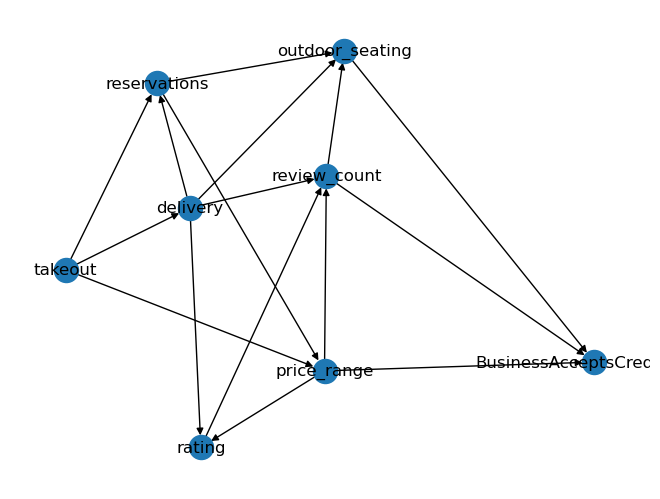

In [19]:
import networkx as nx
import matplotlib.pyplot as plt

# visualize graph
G = nx.DiGraph()
G.add_edges_from(model.edges())
nx.draw(G, with_labels=True)
plt.show()